In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from scipy.optimize import curve_fit
import pandas as pd
from impedance.models.circuits import CustomCircuit


def get_header_lines(filepath):
    with open(filepath, "r", encoding="latin-1") as f:
        # Skip first line, read second
        f.readline()  
        line2 = f.readline().strip()
    # line2 looks like: "Nb header lines : 76"
    # split by ":" and take the right part
    try:
        n_header = int(line2.split(":")[1])
    except Exception:
        raise ValueError(f"Could not parse header line: {line2}")
    return n_header
cmap = plt.get_cmap('rainbow')



In [2]:
# s282 = {'name' : '282', 'comp' : '0 O2','%' : 0.33}
# MEA = [s282]

# for mea in MEA:
#     # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements\2025\286_III_III IrOx series 0 sccm O2 15 sccm Ar, new flow controller\interruptions/'+'*'+mea['name']+'*'))
#     mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements\2025\286_III_III IrOx series 0 sccm O2 15 sccm Ar, new flow controller\interruptions/'))

#     mea['files'] =  glob(os.path.join(mea['folder'][0],'*batch1*'+'*PEIS*'+'*.mpt'))

    
s282 = {'name' : '282', 'comp' : '30 Ir 30 C'}
MEA = [s282]

for mea in MEA:
    # mea['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2025/'+'*'+mea['name']+'*'))
    # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
    folder = r"C:/Users/Herman/Desktop/"
    mea['files'] =  glob(os.path.join(folder,'*batch2_3_batch1_interruptions_1,56V_01_PEIS_C01.mpt'))
    print(mea['files'])
        
for file in mea['files']:
    print(file)
#     print((n-n%3)/3)
#     file = s244['files'][int((n-n%3)/3)]
    # file = s244['files'][n]
    skip_rows = get_header_lines(file)
    with open(file, encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,30),delimiter = '\t')
        
        
    unique_vals = np.unique(df["cycle number"].values)
    # groups = [data[df["cycle number"].values == val] for val in unique_vals]
    
#     R_inf_DRT_list = []
#     L_0_DRT_list = []
#     gamma_DRT_list = []
#     # Z_DRT_list = [0]*len(unique_vals)
#     # Z_exp_list = [0]*len(unique_vals)
    Z_exp_list = []
    freq_list = []
    I_list = []
    time_list = []
    E_list = []
#     log_tau_list = []
    
    for val in unique_vals:
        freq_vec = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
        Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        time = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'time/s'].values)
        E = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
        if np.diff(freq_vec).any() <  0:
            print('problem')
        else:
            pass
        print(len(freq_vec))
        print(len(Z_exp))
        Z_exp_list.append(Z_exp)
        freq_list.append(freq_vec)
        I_list.append(I)
        E_list.append(E)
        time_list.append(time)
        # N_freqs = len(freq_vec)
        # N_taus = N_freqs
# Z_exp = Z_exp[9:]
# freq_vec = freq_vec[9:]
# print(Z_exp.real)

['C:/Users/Herman/Desktop\\batch2_3_batch1_interruptions_1,56V_01_PEIS_C01.mpt']
C:/Users/Herman/Desktop\batch2_3_batch1_interruptions_1,56V_01_PEIS_C01.mpt
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29


C:\Users\Herman\AppData\Local\Temp\ipykernel_8012\3084929189.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


Error in callback <function _draw_all_if_interactive at 0x000001855DBA2E50> (for post_execute):


KeyboardInterrupt: 

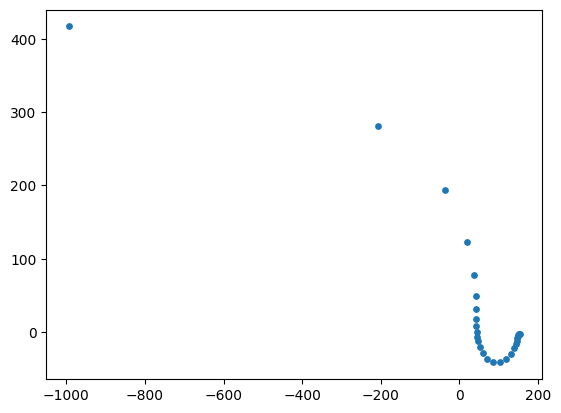

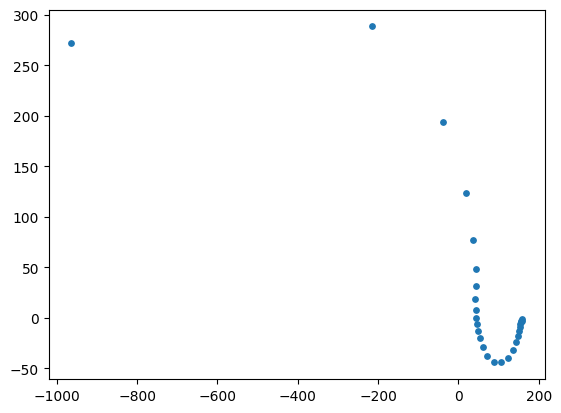

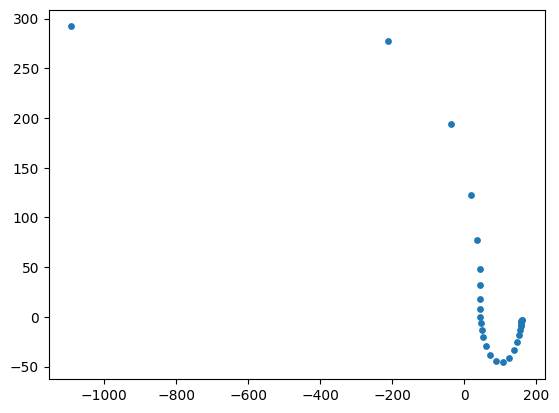

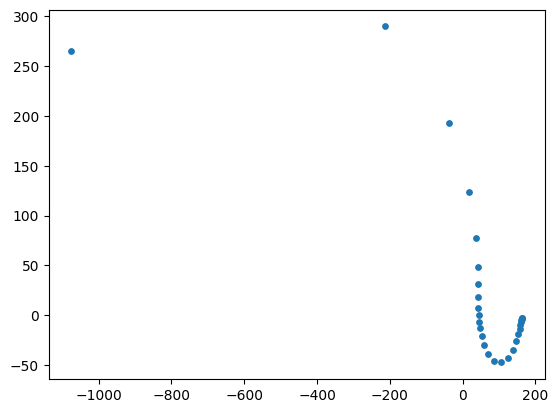

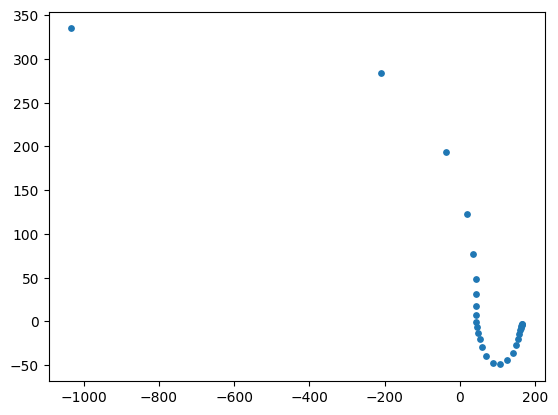

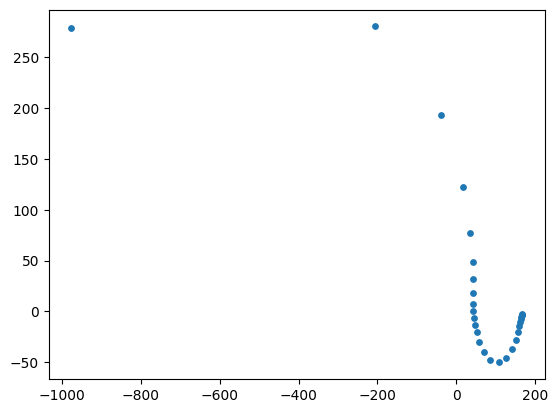

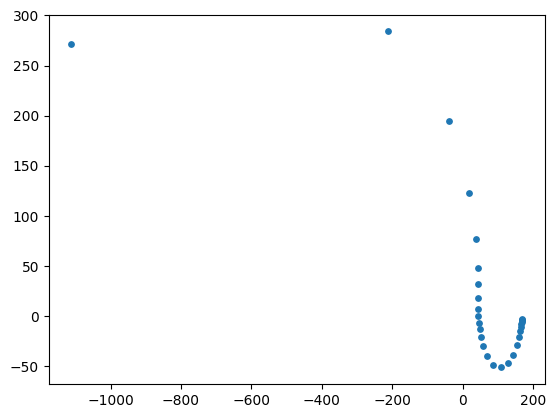

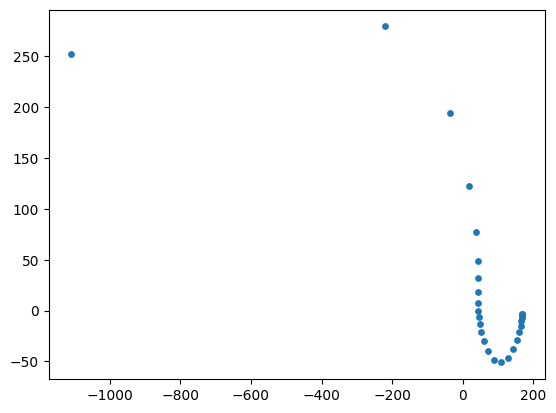

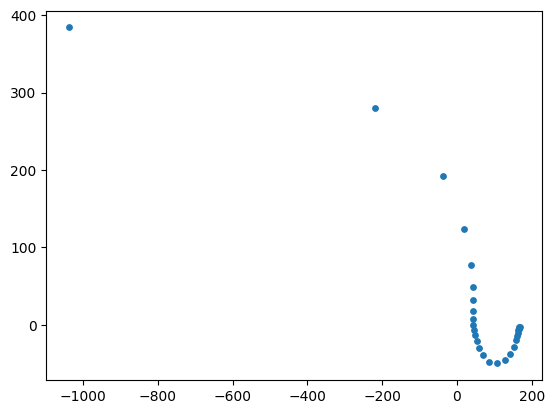

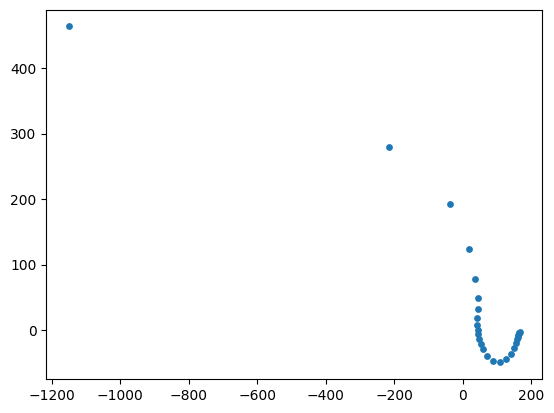

Error in callback <function flush_figures at 0x0000018560F5B040> (for post_execute):


KeyboardInterrupt: 

In [6]:
for Z_exp in Z_exp_list:
    fig, ax = plt.subplots()
    area=4.62
    # experimental data
    ax.scatter(
        Z_exp.real * area * 1000,
        Z_exp.imag * area * 1000,
        s=15,
        label='239, PEIS, cycle 7'
    )
 

In [6]:
# %matplotlib widget
area = 1
init = [0,0,0,0,0]
params_all = []
for i,Z_exp in enumerate(Z_exp_list[0:10]):
    print(len(Z_exp_list[i]))
    print(len(freq_list[i]))
    freq_vec = freq_list[i]
    # 1) Frequency mask – only fit 0.1–1e5 Hz and f > 0
    mask = (freq_vec > 0) & (freq_vec >= 3) & (freq_vec <= 2e4)
    mask &= np.isfinite(Z_exp.real) & np.isfinite(Z_exp.imag)


    f_fit = freq_vec[mask]
    Z_fitdata = Z_exp[mask]

    # 2) Circuit definition
    # cir = 'L0-R0-p(R1,CPE1)-p(R2,CPE2)'
    cir = 'R0-L0-p(R1,CPE1)'
    if np.array(init).any() == 0:
        init = [0.01,10e-8, 0.025, 0.09, 0.8]
    else:
        pass

    bounds = (
        [0.005,0, 0, 1e-3, 0.6],    
        [np.inf,1, np.inf, 1, 1]
    )

    from impedance.models.circuits import CustomCircuit
    circuit = CustomCircuit(cir, initial_guess=init)

    # Fit only masked frequencies
    circuit.fit(f_fit, Z_fitdata, bounds=bounds)
    # print(type(circuit))

    params = circuit.parameters_
    errors = circuit.conf_
    print(errors)
    metadata = [np.mean(time_list[i]),np.mean(E_list[i]),np.mean(I_list[i])]
    params_all.append(np.concatenate((metadata,params,errors)))
    Z_model = circuit.predict(f_fit)
    
    print('parametry: ',params)
    init = params
    # circuit.save(file[:-4]+'_DRT.json')

#     # 3) Plot
#     fig, ax = plt.subplots()

#     # # --- PLOT ALL POINTS (grey) ---
#     # ax.scatter(
#     #     Z_exp.real * area * 1000,
#     #     -Z_exp.imag * area * 1000,
#     #     s=20,
#     #     color='lightgray',
#     #     label='Excluded points'
#     # )

#     # --- PLOT ONLY FITTED POINTS (colored) ---
#     ax.scatter(
#         Z_fitdata.real * area * 1000,
#         -Z_fitdata.imag * area * 1000,
#         s=20,
#         color='blue',
#         label='Used for fit'
#     )

#     # --- PLOT FIT ---
#     ax.plot(
#         Z_model.real * area * 1000,
#         -Z_model.imag * area * 1000,
#         color='black',
#         label='Fit'
#     )

#     # Unique legend
#     handles, labels = ax.get_legend_handles_labels()
#     by_label = dict(zip(labels, handles))
#     ax.legend(by_label.values(), by_label.keys(), frameon=False, bbox_to_anchor=(0.5, 1.2))

#     # Labels
#     if area == 1:
#         ax.set_xlabel(r'Re Z / m$\Omega$')
#         ax.set_ylabel(r'-Im Z / m$\Omega$')
#     else:
#         ax.set_xlabel(r'Re Z / m$\Omega$ cm$^{-2}$')
#         ax.set_ylabel(r'-Im Z / m$\Omega$ cm$^{-2}$')

#     ax.set_aspect('equal', 'box')
#     plt.tight_layout()
#     plt.show()
params_all = np.array(params_all)

29
29
[5.04897904e-05 9.00641666e-10 7.58816778e-05 1.93456217e-03
 3.42769211e-03]
parametry:  [8.93439280e-03 5.11200989e-08 2.37435027e-02 8.24752422e-02
 8.37729491e-01]
29
29
[4.46549550e-05 8.13476918e-10 6.75774796e-05 1.54775918e-03
 2.94938617e-03]
parametry:  [8.97904943e-03 5.06460906e-08 2.47830006e-02 7.68413096e-02
 8.46766889e-01]
29
29
[4.80865677e-05 8.81194542e-10 7.32180195e-05 1.61870617e-03
 3.09982181e-03]
parametry:  [8.96804350e-03 5.08019420e-08 2.55594511e-02 7.66924464e-02
 8.46550445e-01]
29
29
[5.02964774e-05 9.28421317e-10 7.68881220e-05 1.63048174e-03
 3.18818657e-03]
parametry:  [8.97241905e-03 5.08762579e-08 2.61517305e-02 7.52366058e-02
 8.48750278e-01]
29
29
[6.17202940e-05 1.15169038e-09 9.45484857e-05 1.89248527e-03
 3.87316584e-03]
parametry:  [9.00739942e-03 5.04998445e-08 2.65987904e-02 7.19148705e-02
 8.54689191e-01]
29
29
[5.36837328e-05 1.01355417e-09 8.24199506e-05 1.55916102e-03
 3.34376870e-03]
parametry:  [9.07368632e-03 5.00781812e-08 2.6

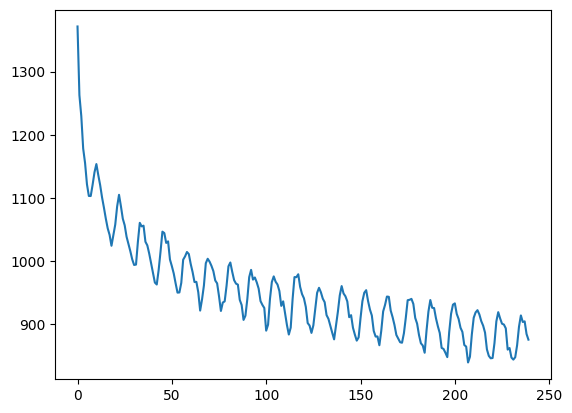

In [41]:
# plt.close()
# print((params_all)[1,:])
# print(str(circuit.get_param_names()[1]))
header = 'time/s'+'\t'+'E/V'+'\t'+'I/mA'+'\t'
for i,name in enumerate(circuit.get_param_names()[0]):
    header = header + str(circuit.get_param_names()[0][i]) + '/' + str(circuit.get_param_names()[1][i]) + '\t'
# print(header)
np.savetxt(file[:-4]+'_EIS.txt', params_all, delimiter='\t', header = header)
plt.plot(params_all[:,2])
plt.show()

## Data plotting

C:/Users/Herman/Desktop\batch2_3_batch1_interruptions_1,56V_01_PEIS_C01_EIS.txt
C:/Users/Herman/Desktop\batch2_3_batch1_interruptions_1,56V_03_PEIS_C01_EIS.txt


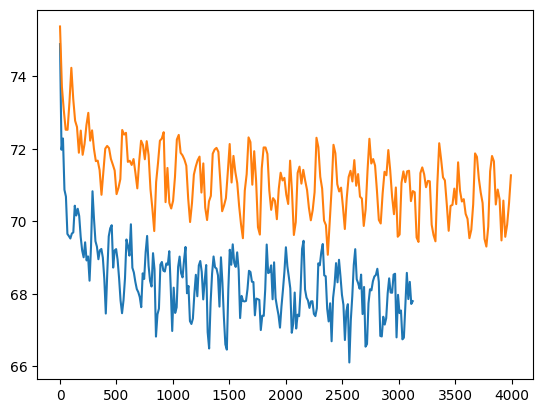

In [59]:

s282 = {'name' : '282', 'comp' : '30 Ir 30 C'}
MEA = [s282]

    # mea['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2025/'+'*'+mea['name']+'*'))
    # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
folder = r"C:/Users/Herman/Desktop/"
mea['files'] =  glob(os.path.join(folder,'*batch2_3_batch1_interruptions_1,56V_*'+'*_PEIS_C01_EIS.txt'))
for file in mea['files']:
    print(file)
    with open(file, encoding='latin1') as f:
        df = pd.read_csv(f,delimiter = '\t')

    time = df['time/s'].values
    I = df['I/mA'].values
    Ro = df['R0/Ohm'].values
    Rct = df['R1/Ohm'].values
    plt.plot(time-time[0],2.3*Rct*I)
plt.show()

## More files EIS fitting and export:

In [42]:
s282 = {'name' : '282', 'comp' : '30 Ir 30 C'}
MEA = [s282]

for mea in MEA:
    # mea['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2025/'+'*'+mea['name']+'*'))
    # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
    folder = r"C:/Users/Herman/Desktop/"
    mea['files'] =  glob(os.path.join(folder,'*batch2_3_batch1_interruptions_1,56V_*'+'*_PEIS_C01.mpt'))
    print(mea['files'])
        
for file in mea['files']:
    print(file)
#     print((n-n%3)/3)
#     file = s244['files'][int((n-n%3)/3)]
    # file = s244['files'][n]
    skip_rows = get_header_lines(file)
    with open(file, encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,30),delimiter = '\t')
        
        
    unique_vals = np.unique(df["cycle number"].values)

    Z_exp_list = []
    freq_list = []
    I_list = []
    time_list = []
    E_list = []

    
    for val in unique_vals:
        freq_vec = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
        Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        time = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'time/s'].values)
        E = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
        if np.diff(freq_vec).any() <  0:
            print('problem')
        else:
            pass

        Z_exp_list.append(Z_exp)
        freq_list.append(freq_vec)
        I_list.append(I)
        E_list.append(E)
        time_list.append(time)

    init = [0,0,0,0,0]
    params_all = []
    for i,Z_exp in enumerate(Z_exp_list):
        print(len(Z_exp_list[i]))
        print(len(freq_list[i]))
        freq_vec = freq_list[i]
        # 1) Frequency mask – only fit 0.1–1e5 Hz and f > 0
        mask = (freq_vec > 0) & (freq_vec >= 3) & (freq_vec <= 2e4)
        mask &= np.isfinite(Z_exp.real) & np.isfinite(Z_exp.imag)


        f_fit = freq_vec[mask]
        Z_fitdata = Z_exp[mask]

        # 2) Circuit definition
        # cir = 'L0-R0-p(R1,CPE1)-p(R2,CPE2)'
        cir = 'R0-L0-p(R1,CPE1)'
        if np.array(init).any() == 0:
            init = [0.01,10e-8, 0.025, 0.09, 0.8]
        else:
            pass

        bounds = (
            [0.005,0, 0, 1e-3, 0.6],    
            [np.inf,1, np.inf, 1, 1]
        )

        from impedance.models.circuits import CustomCircuit
        circuit = CustomCircuit(cir, initial_guess=init)

        # Fit only masked frequencies
        circuit.fit(f_fit, Z_fitdata, bounds=bounds)
        # print(type(circuit))

        params = circuit.parameters_
        errors = circuit.conf_
        metadata = [np.mean(time_list[i]),np.mean(E_list[i]),np.mean(I_list[i])]
        params_all.append(np.concatenate((metadata,params,errors)))
        Z_model = circuit.predict(f_fit)

        print('parametry: ',params)
        init = params

    params_all = np.array(params_all)
    header = 'time/s'+'\t'+'E/V'+'\t'+'I/mA'+'\t'
    for i,name in enumerate(circuit.get_param_names()[0]):
        header = header + str(circuit.get_param_names()[0][i]) + '/' + str(circuit.get_param_names()[1][i]) + '\t'

    np.savetxt(file[:-4]+'_EIS.txt', params_all, delimiter='\t', header = header)

['C:/Users/Herman/Desktop\\batch2_3_batch1_interruptions_1,56V_01_PEIS_C01.mpt', 'C:/Users/Herman/Desktop\\batch2_3_batch1_interruptions_1,56V_03_PEIS_C01.mpt']
C:/Users/Herman/Desktop\batch2_3_batch1_interruptions_1,56V_01_PEIS_C01.mpt
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
2